In [127]:
!pip install -U prosperity3bt

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 5.3 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [69]:
# Load packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as st
import math as mt
import seaborn as sns
from arch.unitroot import ADF, KPSS
#!pip install arch has previously been run
from arch.unitroot.cointegration import phillips_ouliaris
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ardl import UECM
from statsmodels.tsa.api import VAR
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS

In [70]:
csvmin1 = pd.read_csv("round-1-island-data-bottle/prices_round_1_day_0.csv")
csvmin2 = pd.read_csv("round-1-island-data-bottle/prices_round_1_day_0.csv")
csv0 = pd.read_csv("round-1-island-data-bottle/prices_round_1_day_0.csv")

dfmin1 = pd.DataFrame(csvmin1)
dfmin2 = pd.DataFrame(csvmin2)
df0 = pd.DataFrame(csv0)

In [71]:
# Making super dataframe with kelp, squid, epsilon
merged_df = df0kelp.join(df0squid["mid_price"].rename("mid_price_squid"))
#merged_df = merged_df.join(epsilon_tminus1.rename("epsilon_tminus1"))
#merged_df = merged_df[['timestamp', 'mid_price', 'mid_price_squid', 'epsilon_tminus1']]
merged_df = merged_df.rename(columns={'mid_price': 'mid_price_kelp'})

In [72]:
##Day -1 dataframes for all products
dfmin1resin = dfmin1[dfmin1['product'] == 'RAINFOREST_RESIN']
dfmin1kelp = dfmin1[dfmin1['product'] == 'KELP']
dfmin1squid = dfmin1[dfmin1['product'] == 'SQUID_INK']
##Day -2 dataframes for all products
dfmin2resin = dfmin2[dfmin2['product'] == 'RAINFOREST_RESIN']
dfmin2kelp = dfmin2[dfmin2['product'] == 'KELP']
dfmin2squid = dfmin2[dfmin2['product'] == 'SQUID_INK']

##Day zero prices for all prodcuts
df0resin = df0[df0['product'] == 'RAINFOREST_RESIN']
df0kelp = df0[df0['product'] == 'KELP']
df0squid = df0[df0['product'] == 'SQUID_INK']

In [73]:
spreadMean = (df0kelp["ask_price_1"] - df0kelp["bid_price_1"]).mean()
print(spreadMean)

2.7292


In [74]:
#Head for all the dataframes

dfmin1resin.head(20)
#dfmin1kelp.head(20)
#dfmin1squid.head(20)

#dfmin2resin.head(20)
#dfmin2kelp.head(20)
#dfmin2squid.head(20)

#df0resin.head(20)
#df0kelp.head(20)
#df0squid.head(20)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,RAINFOREST_RESIN,9998,1,9995.0,30.0,NaN,NaN,10005,30,NaN,NaN,NaN,NaN,10001.5,0.0
5,0,100,RAINFOREST_RESIN,9996,1,9995.0,30.0,NaN,NaN,10002,6,10004.0,1.0,10005.0,30.0,9999.0,0.0
7,0,200,RAINFOREST_RESIN,9996,1,9995.0,21.0,NaN,NaN,10004,1,10005.0,21.0,NaN,NaN,10000.0,0.0
11,0,300,RAINFOREST_RESIN,9996,2,9995.0,23.0,NaN,NaN,9998,3,10004.0,2.0,10005.0,23.0,9997.0,0.0
12,0,400,RAINFOREST_RESIN,9998,5,9996.0,2.0,9995.0,23.0,10004,2,10005.0,23.0,NaN,NaN,10001.0,0.0
17,0,500,RAINFOREST_RESIN,10002,1,9996.0,2.0,9995.0,22.0,10004,2,10005.0,22.0,NaN,NaN,10003.0,0.0
19,0,600,RAINFOREST_RESIN,9996,2,9995.0,24.0,NaN,NaN,10002,9,10004.0,2.0,10005.0,24.0,9999.0,0.0
23,0,700,RAINFOREST_RESIN,9998,7,9995.0,27.0,NaN,NaN,10005,27,NaN,NaN,NaN,NaN,10001.5,0.0
24,0,800,RAINFOREST_RESIN,9995,26,NaN,NaN,NaN,NaN,10005,26,NaN,NaN,NaN,NaN,10000.0,0.0
29,0,900,RAINFOREST_RESIN,9996,2,9995.0,27.0,NaN,NaN,10004,2,10005.0,27.0,NaN,NaN,10000.0,0.0


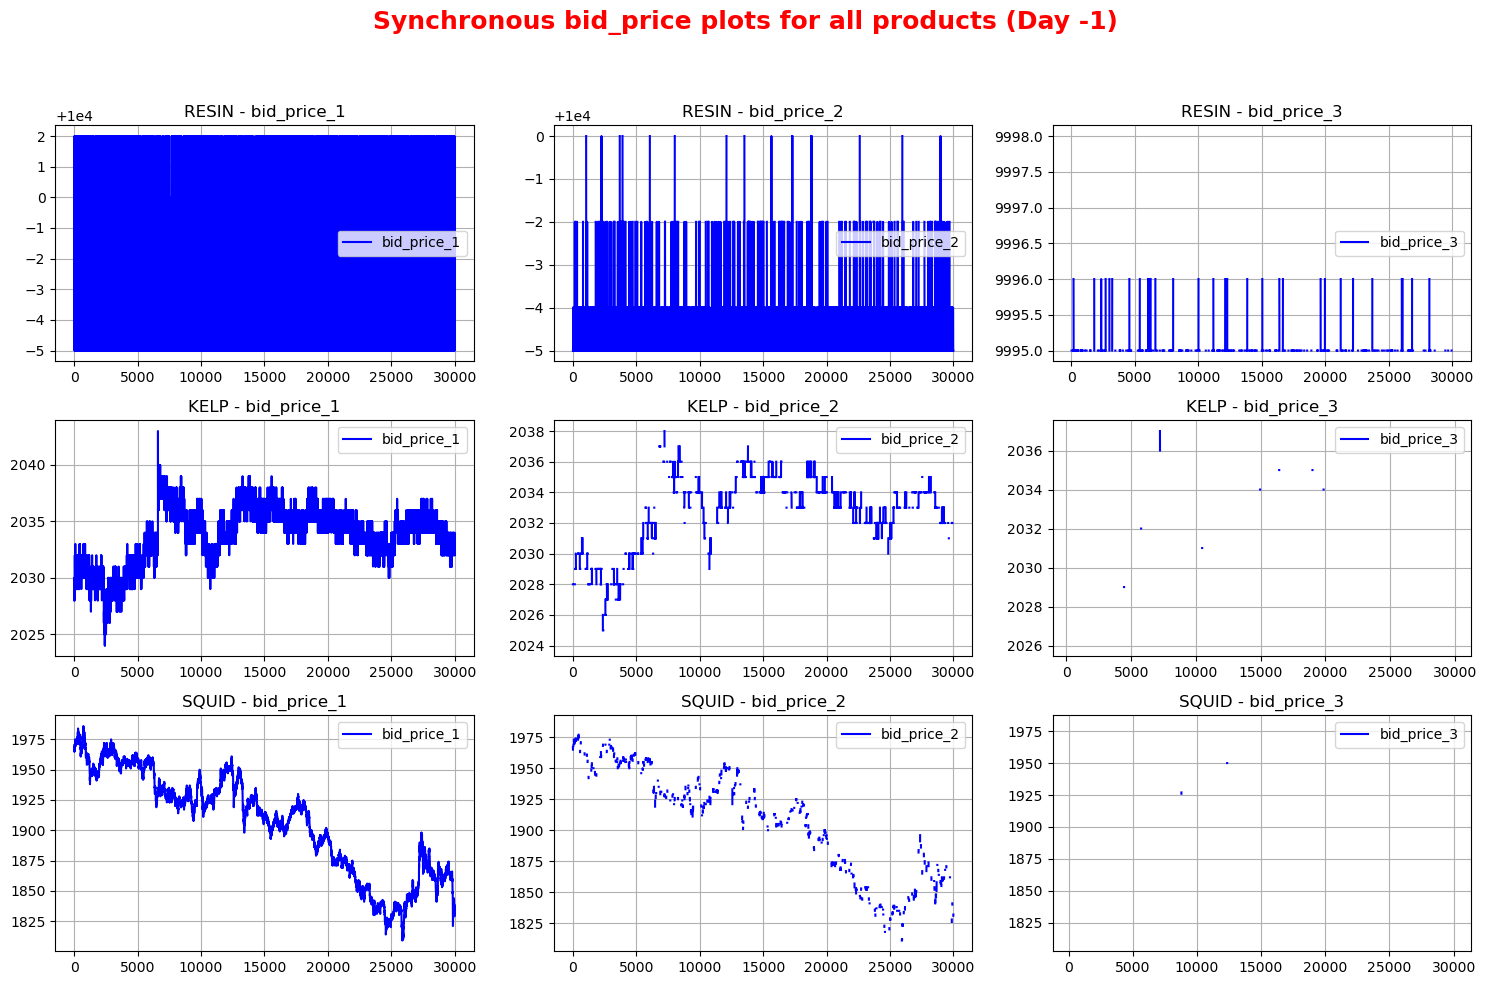

In [75]:
# Synchronous bid_price plots for all products (Day -1)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # 3 rows (products), 3 columns (bid prices)

# DataFrames for Day -1
dfs = [dfmin1resin, dfmin1kelp, dfmin1squid]
product_names = ['RESIN', 'KELP', 'SQUID']
bid_columns = ["bid_price_1", "bid_price_2", "bid_price_3"]

# Iterate over rows (products)
for row_idx, (df, name) in enumerate(zip(dfs, product_names)):
    for col_idx, col in enumerate(bid_columns):
        axes[row_idx, col_idx].plot(df[col], label=col, color="blue")
        axes[row_idx, col_idx].set_title(f"{name} - {col}")
        axes[row_idx, col_idx].legend()
        axes[row_idx, col_idx].grid()

# Add a bold red supertitle and leave space for it
plt.suptitle("Synchronous bid_price plots for all products (Day -1)", 
             fontsize=18, color='red', fontweight='bold')

# Adjust layout to prevent overlap with supertitle
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

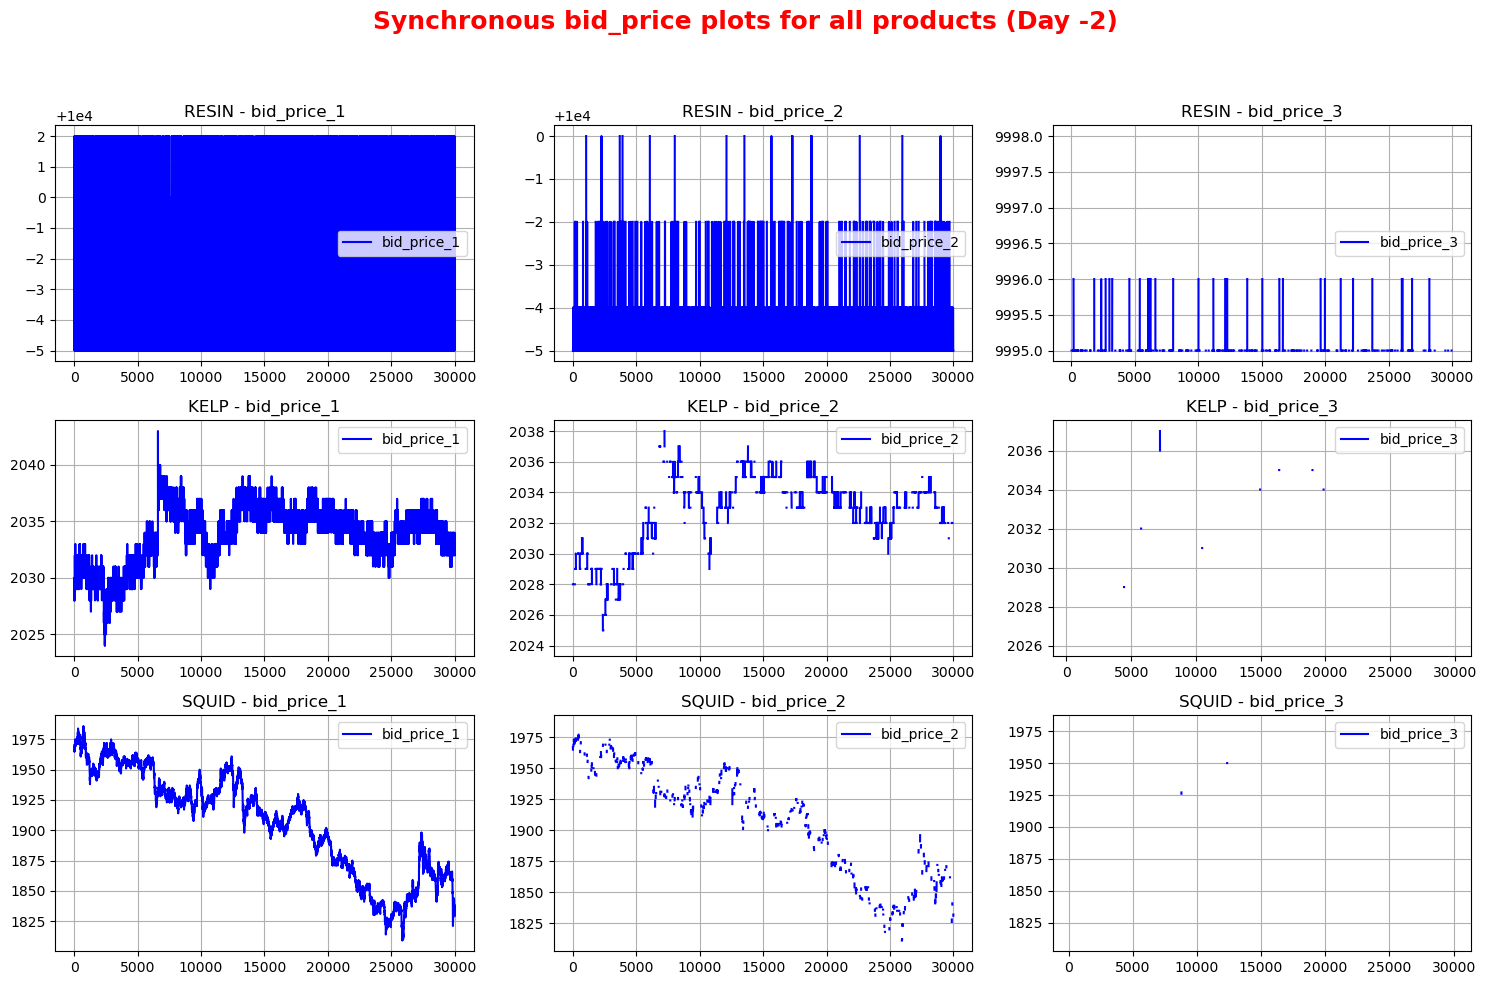

In [76]:
# Synchronous bid_price plots for all products (Day -2)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # 3 rows (products), 3 columns (bid prices)

# DataFrames for Day -1
dfs = [dfmin2resin, dfmin2kelp, dfmin2squid]
product_names = ['RESIN', 'KELP', 'SQUID']
bid_columns = ["bid_price_1", "bid_price_2", "bid_price_3"]

# Iterate over rows (products)
for row_idx, (df, name) in enumerate(zip(dfs, product_names)):
    for col_idx, col in enumerate(bid_columns):
        axes[row_idx, col_idx].plot(df[col], label=col, color="blue")
        axes[row_idx, col_idx].set_title(f"{name} - {col}")
        axes[row_idx, col_idx].legend()
        axes[row_idx, col_idx].grid()

# Add a bold red supertitle and leave space for it
plt.suptitle("Synchronous bid_price plots for all products (Day -2)", 
             fontsize=18, color='red', fontweight='bold')

# Adjust layout to prevent overlap with supertitle
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


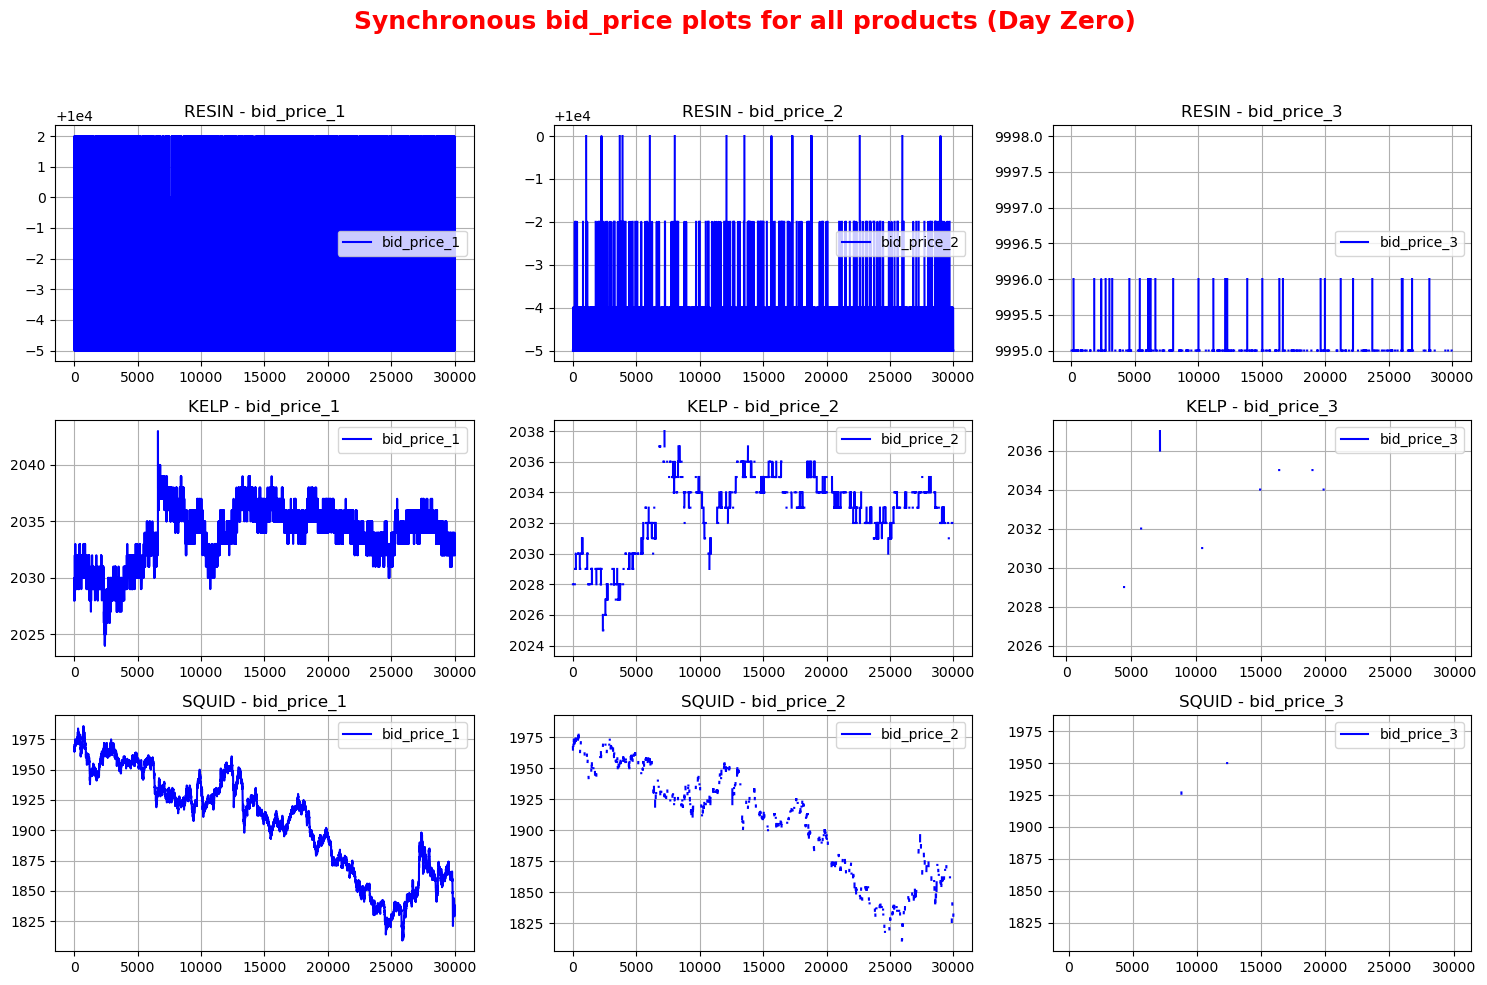

In [77]:
# Synchronous bid_price plots for all products (Day 0)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # 3 rows (products), 3 columns (bid prices)

# DataFrames for Day -1
dfs = [dfmin2resin, dfmin2kelp, dfmin2squid]
product_names = ['RESIN', 'KELP', 'SQUID']
bid_columns = ["bid_price_1", "bid_price_2", "bid_price_3"]

# Iterate over rows (products)
for row_idx, (df, name) in enumerate(zip(dfs, product_names)):
    for col_idx, col in enumerate(bid_columns):
        axes[row_idx, col_idx].plot(df[col], label=col, color="blue")
        axes[row_idx, col_idx].set_title(f"{name} - {col}")
        axes[row_idx, col_idx].legend()
        axes[row_idx, col_idx].grid()

# Add a bold red supertitle and leave space for it
plt.suptitle("Synchronous bid_price plots for all products (Day Zero)", 
             fontsize=18, color='red', fontweight='bold')

# Adjust layout to prevent overlap with supertitle
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\335492988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bid_ask_spread_1"] = df["ask_price_1"] - df["bid_price_1"]
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\335492988.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bid_ask_spread_2"] = df["ask_price_2"] - df["bid_price_2"]
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\335492988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

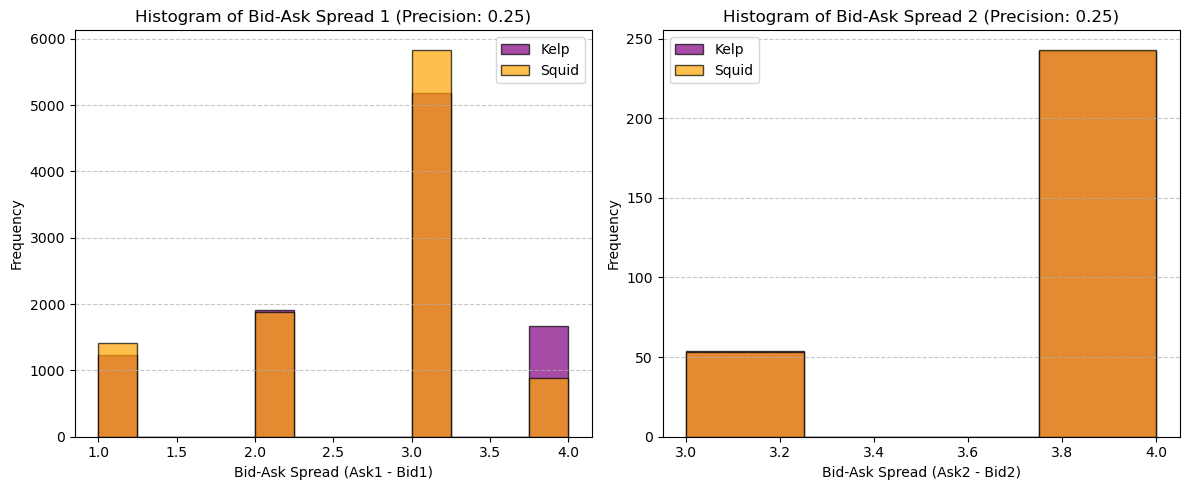

In [78]:

# Function to compute bid-ask spread 1
def compute_bid_ask_spread_1(df):
    df["bid_ask_spread_1"] = df["ask_price_1"] - df["bid_price_1"]
    return df

# Function to compute bid-ask spread 2
def compute_bid_ask_spread_2(df):
    df["bid_ask_spread_2"] = df["ask_price_2"] - df["bid_price_2"]
    return df

# Assuming df0kelp and df0squid are already defined
# Compute the spreads for both datasets
df0kelp = compute_bid_ask_spread_1(df0kelp)
df0kelp = compute_bid_ask_spread_2(df0kelp)
df0squid = compute_bid_ask_spread_1(df0squid)
df0squid = compute_bid_ask_spread_2(df0squid)

# Create 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for bid_ask_spread_1 for both datasets (side-by-side bars)
bin_edges_1 = np.arange(min(df0kelp["bid_ask_spread_1"].min(), df0squid["bid_ask_spread_1"].min()), 
                        max(df0kelp["bid_ask_spread_1"].max(), df0squid["bid_ask_spread_1"].max()) + 0.25, 0.25)

axes[0].hist(df0kelp["bid_ask_spread_1"], bins=bin_edges_1, 
             color="purple", edgecolor="black", alpha=0.7, label="Kelp")
axes[0].hist(df0squid["bid_ask_spread_1"], bins=bin_edges_1, 
             color="orange", edgecolor="black", alpha=0.7, label="Squid")

axes[0].set_xlabel("Bid-Ask Spread (Ask1 - Bid1)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Bid-Ask Spread 1 (Precision: 0.25)")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].legend()

# Histogram for bid_ask_spread_2 for both datasets (side-by-side bars)
bin_edges_2 = np.arange(min(df0kelp["bid_ask_spread_2"].min(), df0squid["bid_ask_spread_2"].min()), 
                        max(df0kelp["bid_ask_spread_2"].max(), df0squid["bid_ask_spread_2"].max()) + 0.25, 0.25)

axes[1].hist(df0kelp["bid_ask_spread_2"], bins=bin_edges_2, 
             color="purple", edgecolor="black", alpha=0.7, label="Kelp")
axes[1].hist(df0squid["bid_ask_spread_2"], bins=bin_edges_2, 
             color="orange", edgecolor="black", alpha=0.7, label="Squid")

axes[1].set_xlabel("Bid-Ask Spread (Ask2 - Bid2)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Histogram of Bid-Ask Spread 2 (Precision: 0.25)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()


C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\335492988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bid_ask_spread_1"] = df["ask_price_1"] - df["bid_price_1"]
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\335492988.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bid_ask_spread_2"] = df["ask_price_2"] - df["bid_price_2"]


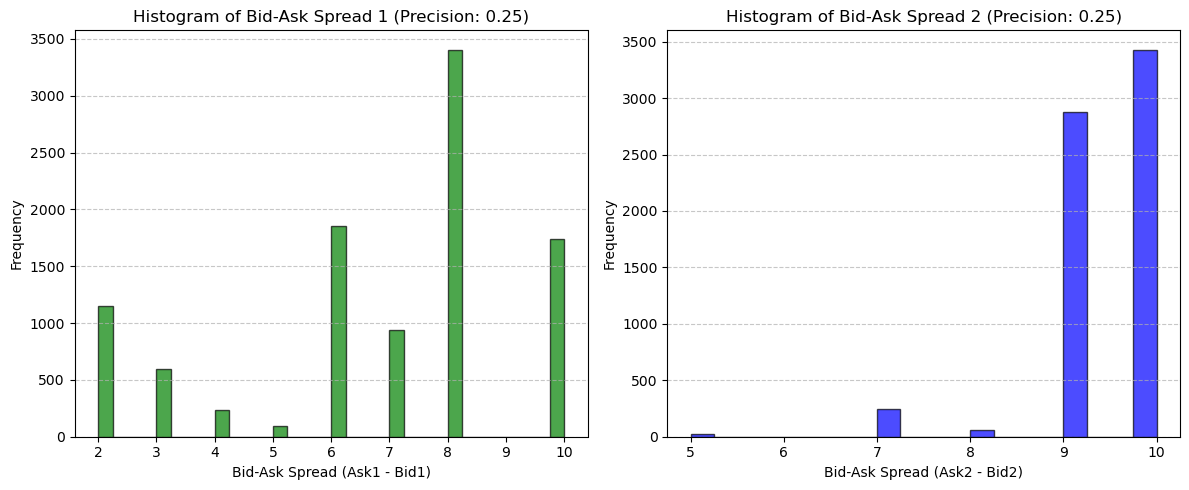

In [79]:
# Assuming df0resin is already defined
# Compute the spreads for df0resin
df0resin = compute_bid_ask_spread_1(df0resin)
df0resin = compute_bid_ask_spread_2(df0resin)

# Create 1x2 subplot for df0resin
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for bid_ask_spread_1 for df0resin
bin_edges_1 = np.arange(df0resin["bid_ask_spread_1"].min(), 
                        df0resin["bid_ask_spread_1"].max() + 0.25, 0.25)

axes[0].hist(df0resin["bid_ask_spread_1"], bins=bin_edges_1, 
             color="green", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Bid-Ask Spread (Ask1 - Bid1)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Bid-Ask Spread 1 (Precision: 0.25)")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Histogram for bid_ask_spread_2 for df0resin
bin_edges_2 = np.arange(df0resin["bid_ask_spread_2"].min(), 
                        df0resin["bid_ask_spread_2"].max() + 0.25, 0.25)

axes[1].hist(df0resin["bid_ask_spread_2"], bins=bin_edges_2, 
             color="blue", edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Bid-Ask Spread (Ask2 - Bid2)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Histogram of Bid-Ask Spread 2 (Precision: 0.25)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()


In [80]:
# ADF Test Results with 5% Significance Level for GOOGLE, EURUSD, UST10Y
resin0ADF = ADF(df0resin["mid_price"], trend="n", method="bic")
kelp0ADF= ADF(df0kelp["mid_price"], trend="n", method="bic")
squid0ADF = ADF(df0squid["mid_price"], trend="n", method="bic")

pd.DataFrame(
    {
        "Resin mid Price": (resin0ADF.stat, resin0ADF.critical_values["5%"]),
        "| Kelp mid price": (kelp0ADF.stat, kelp0ADF.critical_values["5%"]),
        "| Squid mid price": (
            squid0ADF.stat,
            squid0ADF.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

,Resin mid Price,| Kelp mid price,| Squid mid price
ADF Test Statistic,-0.030353,0.210700,-1.257835
5% Critical Value,-1.941027,-1.941027,-1.941027


<span style="color:red">For kelp and squid ink: ADF test-statistic > 5% critical value => hence, we can reject the null, unit root exists, non-stationary.  The resin is also non stationary</span>


In [82]:
kelpdiff0 = df0kelp["mid_price"].diff().dropna()
squiddiff0 = df0squid["mid_price"].diff().dropna()



In [83]:
#Running ADF test on the difference of Kelp and Squid
kelpdiffADF= ADF(kelpdiff0, trend="n", method="bic")
squidiff0ADF = ADF(squiddiff0, trend="n", method="bic")

pd.DataFrame(
    {
        " Diff 1 Kelp mid price": (kelpdiffADF.stat, kelpdiffADF.critical_values["5%"]),
        "| Diff 1 Squid mid price": (
            squidiff0ADF.stat,
            squidiff0ADF.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

,Diff 1 Kelp mid price,| Diff 1 Squid mid price
ADF Test Statistic,-45.439934,-123.568952
5% Critical Value,-1.941027,-1.941027


<span style="color:red">For kelp and squid ink: ADF test-statistic < 5% critical value => hence, we can reject the null, The Diff is stationary. ==> Both Kelp and Squid are I(1) . </span>


In [85]:

# Find the common indices
common_indices = df0kelp["mid_price"].index.intersection(df0squid["mid_price"].index)

# Reindex both Series to the common indices
squid_aligned = df0squid["mid_price"].reindex(common_indices)

In [86]:
df0kelp = df0kelp.reset_index(drop=True)
df0squid = df0squid.reset_index(drop=True)

In [87]:
print(df0kelp["mid_price"].index)
print(df0squid["mid_price"].index)

RangeIndex(start=0, stop=10000, step=1)
RangeIndex(start=0, stop=10000, step=1)


In [88]:
# Two-Step Residual Based Test for Cointegration for Kelp and Squid
 # (aka Phillips and Ouliaris cointegration test)
print(phillips_ouliaris(df0kelp["mid_price"], df0squid["mid_price"], trend="c", test_type="Za", kernel="bartlett"))

Phillips-Ouliaris Za Cointegration Test
Statistic: -1099.2229828089417
P-value: 0.0
Null: No Cointegration, Alternative: Cointegration
Kernel: Bartlett
Bandwidth: 68.272
Trend: c
Distribution Order: 3


<span style="color:red; font-weight:bold; font-size:22px;">
  P-value is less than 0.05 => We can reject the null => Kelp and Squid are cointegrated.
</span>


In [90]:
#Running the Error Correction Model (ECM) to get the parameters - KELP on Squid
ecm_model_kelp_as_y = UECM(
    endog=pd.DataFrame(df0kelp["mid_price"]),
    lags=1,
    exog=pd.DataFrame(df0squid["mid_price"]),
    order=1,
    trend="c",
 ).fit()
print(ecm_model_kelp_as_y.summary())

                              UECM Model Results                              
Dep. Variable:            D.mid_price   No. Observations:                10000
Model:                     UECM(1, 1)   Log Likelihood              -10647.951
Method:               Conditional MLE   S.D. of innovations           2034.553
Date:                Thu, 10 Apr 2025   AIC                          21305.901
Time:                        10:24:29   BIC                          21341.953
Sample:                             1   HQIC                         21318.105
                                10000                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             98.5265      6.329     15.566      0.000      86.119     110.934
mid_price.L1      -0.0477      0.003    -15.590      0.000      -0.054      -0.042
mid_price.L1      -0.0008      0.000

<span style="color:red; font-weight:bold; font-size:16px;">
  ECM (Kelp on Squid) : Lambda is (-0.0477) which is aligned with the requirements of ECM (Lambda being negative) and between 0 and -1. Meaning : if the Kelp deviates 1 point from the long-term equilibrium with Squid at time t-1 , Squid will drop 0.0477 point at time to bring it back to long-term equilibrium. (It's strange, before running the second ECM, the parameter was 0.0477 but after running the second ECM it changed!)
</span>


In [92]:
# Durbin-Watson Test Result for ECM of KELP on SQUID
print(durbin_watson(ecm_model_kelp_as_y.fittedvalues))

2.1873990927829907


<span style="color:red; font-weight:bold; font-size:16px;">
  Residuals of ECM (Kelp on Squid) : DW parameter is close to 2 => There is no serial autocorrelation among the resisudals of ECM => No information left in the residual => All good ECM is working properly.
</span>


In [94]:
merged_df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price_kelp,profit_and_loss,bid_ask_spread_1,bid_ask_spread_2,mid_price_squid
0,0,0,KELP,2028,30,NaN,NaN,NaN,NaN,2032,30,NaN,NaN,NaN,NaN,2030.0,0.0,4,NaN,1969.5
1,0,100,KELP,2030,4,2028.0,31.0,NaN,NaN,2032,31,NaN,NaN,NaN,NaN,2031.0,0.0,2,NaN,1970.0
2,0,200,KELP,2029,1,2028.0,21.0,NaN,NaN,2032,22,NaN,NaN,NaN,NaN,2030.5,0.0,3,NaN,1967.5
3,0,300,KELP,2029,25,NaN,NaN,NaN,NaN,2032,25,NaN,NaN,NaN,NaN,2030.5,0.0,3,NaN,1966.5
4,0,400,KELP,2029,2,2028.0,23.0,NaN,NaN,2030,6,2032.0,25.0,NaN,NaN,2029.5,0.0,1,4.0,1967.0


In [95]:
# y= KELP, X= INK
constant = True
start = merged_df.index[0]         # First date in the index
end = merged_df.index[-1]          # Last date in the index
y_t = merged_df["mid_price_kelp"].loc[start:end].dropna() # 
x_t = merged_df["mid_price_squid"].loc[start:end].dropna()
if constant == True:
    x_t = add_constant(x_t) # add intercept = columns of 1s to x_t
# OLS regression: Static Equilibrium Model
ols = OLS(y_t, x_t).fit()  # validate result with statsmodels
res = ols.resid
# OLS regression: ECM Model
dy_t = merged_df["mid_price_kelp"].loc[start:end].diff(1).dropna() # 
dx_t = merged_df["mid_price_squid"].loc[start:end].diff(1).dropna()
if constant == True:
    dx_t = add_constant(dx_t) # add intercept = columns of 1s to x_t
dx_t['e_t_1'] = res.shift(1)
ols = OLS(dy_t, dx_t).fit()  # validate result with statsmodels
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         mid_price_kelp   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     1119.
Date:                Thu, 10 Apr 2025   Prob (F-statistic):               0.00
Time:                        10:24:29   Log-Likelihood:                -10648.
No. Observations:                9999   AIC:                         2.130e+04
Df Residuals:                    9996   BIC:                         2.132e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0034      0.007      0.483      0.629      -0.010       0.017
mid_price_squid     0.2330      0.005     43.376      0.000       0.222       0.244
e_t_1              -0.0477      0.003    -15.591      0.000      -0.054      -0.042
==============================================================================
Omnibus:                     1798.194   Durbin-Watson:                   2.785
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25453.263
Skew:                           0.441   Prob(JB):                         0.00
Kurtosis:                      10.766   Cond. No.                         2.31
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [96]:
def OU_Process_OLS(y,x, start, end, constant_=True):
    '''
    Returns OU Process OLS and entry/exit output calculated from AR(1) model using OU process:
    e_t = C + B*e_t_1 + eps_t_tau
    where e_t are the residuals from:
    y_t = constant + beta*x_t + e_t
    
    Params
    ------
    y = Dependent Variable e.g. security price level caused by x
    x = Independent Variable e.g. security price level causing y
    start = start date. Format 'YYYY-MM_DD'
    end = end date. Format 'YYYY-MM_DD' 
    constant = True. Constant present in OU process regression. 
    '''
    constant = True
    y_t = y.loc[start:end].dropna() # 
    x_t = x.loc[start:end].dropna()
    if constant == True:
        x_t = add_constant(x_t) # add intercept = columns of 1s to x_t
    # OLS regression: Static Equilibrium Model
    ols = OLS(y_t, x_t).fit()  # validate result with statsmodels
    res = ols.resid
    # OU SDE Solution Regression: e_t = C + B*et_1 + eps_t_tau
    constant = True
    res_t = res[1:] 
    res_t_1 = res.shift(1).dropna()
    if constant == True:
        x = add_constant(res_t_1) # add intercept = columns of 1s to x_t
    x.rename(columns={0: 'res_t_1'}, inplace=True)
    ols = OLS(res_t, x).fit()
    # Entry/Exit Params:
    mu_e = ols.params[0] / (1-ols.params[1]) # equilibrium level
    tau = 1/252 # daily data frequency 
    theta = - np.log(ols.params[1])/tau # speed of reversion
    half_l = np.log(2) / theta #  half life
    sigma_OU = np.sqrt( 2* theta * np.var(ols.resid) / (1- np.exp(-2*theta*tau)) ) # diffusion over small time scale (volatility coming from small ups and downs of BM)
    sigma_eq = sigma_OU / np.sqrt(2*theta)# use to determine exit/trading points = mu_e +/- sigma_eq
    # entry/exit points:
    ee_h = mu_e + sigma_eq
    ee_l = mu_e - sigma_eq
    df_out = {'spread':res,'mu_e':[mu_e],'tau':tau,'theta': theta,
                           'sigma_OU':sigma_OU,'sigma_eq':sigma_eq,
                           'ee_high':ee_h,'ee_low':ee_l}
    print('mu_e = ',mu_e)
    print('tau =', tau)
    print('theta = ', theta)
    print('sigma_OU = ', sigma_OU)
    print('sigma_eq = ', sigma_eq)
    print('high/low entry/exit points:', ee_l, ee_h)
    print('#'*50)
    print('############= OU Process Regression ##############')
    df_plot = pd.DataFrame({'res':res,'ee_h':np.repeat(ee_h,len(res)),'ee_l':np.repeat(ee_l,len(res)),
                            'mu_e':np.repeat(mu_e,len(res))}, index=res.index)
    df_plot.plot()
    return df_out
    

mu_e =  0.002337203961272943
tau = 0.003968253968253968
theta =  15.138994526199
sigma_OU =  12.664496858606427
sigma_eq =  2.301571265124708
high/low entry/exit points: -2.299234061163435 2.303908469085981
##################################################
############= OU Process Regression ##############


C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\1993933976.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mu_e = ols.params[0] / (1-ols.params[1]) # equilibrium level
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\1993933976.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  theta = - np.log(ols.params[1])/tau # speed of reversion


dict_keys(['spread', 'mu_e', 'tau', 'theta', 'sigma_OU', 'sigma_eq', 'ee_high', 'ee_low'])

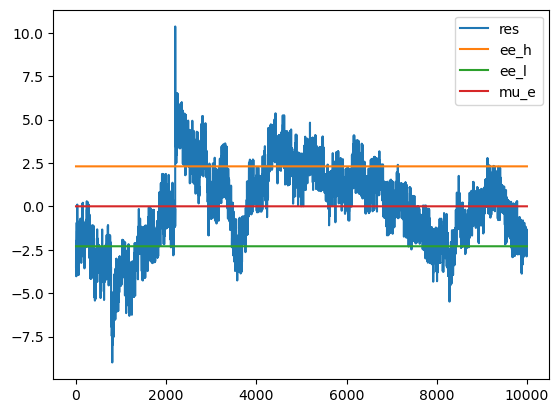

In [97]:
ou_params = OU_Process_OLS(merged_df["mid_price_kelp"], merged_df["mid_price_squid"], start, end, constant_=True)
ou_params.keys()

In [98]:
def spread(y,x, start, end, constant_=True):
    '''
    Returns spread from regression:
    y = constant + 
    '''
    constant = True
    y_t = y.loc[start:end].dropna() 
    x_t = x.loc[start:end].dropna()
    if constant == True:
        x_t = add_constant(x_t) # add intercept = columns of 1s to x_t
    # OLS regression: Static Equilibrium Model
    ols = OLS(y_t, x_t).fit()  # validate result with statsmodels
    res = ols.resid
    return res

In [99]:
def spread_zscore(spread, mean=None, sigma=None):
    if (mean != None and sigma != None):
        return (spread - mean) / sigma
    else:
        return (spread - spread.mean()) / np.std(spread)

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\2408353009.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.legend(['z-score $\hat{e}_t$', '+1 $\sigma_e$', '-1 $\sigma_e$'], loc='lower right')
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\2408353009.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.legend(['z-score $\hat{e}_t$', '+1 $\sigma_e$', '-1 $\sigma_e$'], loc='lower right')
C:\Users\Saeid\AppData\Local\Temp\ipykernel_22760\2408353009.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.legend(['z-score $\hat{e}_t$', '+1 $\sigma_e$', '-1 $\sigma_e$'], loc='lower right')


Text(0.5, 1.0, 'Spread - Z-Score')

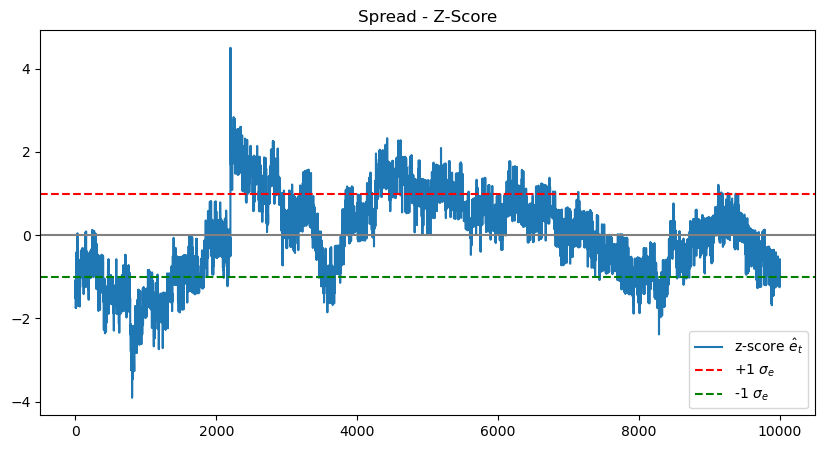

In [100]:
zs = spread_zscore(spread(merged_df["mid_price_kelp"], merged_df["mid_price_squid"], start, end, constant_=True))
zs.plot(figsize=(10,5))
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['z-score $\hat{e}_t$', '+1 $\sigma_e$', '-1 $\sigma_e$'], loc='lower right')
plt.axhline(0, color='grey')
plt.title('Spread - Z-Score')

In [122]:
print(zs)

0      -1.509275
1      -1.071255
2      -1.307312
3      -1.314889
4      -1.745332
          ...   
9995   -1.035015
9996   -1.023650
9997   -0.578053
9998   -1.202884
9999   -0.974403
Length: 10000, dtype: float64


In [124]:
zs.to_excel('output.xlsx', index=False)  # index=False avoids duplicate index column

In [101]:
merged_df.index

RangeIndex(start=0, stop=10000, step=1)

In [102]:
#In-Sample backtesting
# Param Set Up
from VecBacktester_spread import MRVectorBacktester

start_in = merged_df.index[5000]
end_in = merged_df.index[9999]
start = start_in
end = end_in
sp = MRVectorBacktester(merged_df["mid_price_kelp"], merged_df["mid_price_squid"], start, end, start_in, end_in, freq='daily', trans=None, ctf=0.0017, rf=0.02)
sp.run_strategy(sd=1,slip=1)

ModuleNotFoundError: No module named 'VecBacktester_spread'

In [ ]:
'''
#Running OLS of Kelp on Squid to get the parameters alpha and beta
y =df0kelp["mid_price"]
x =df0squid["mid_price"]
#model_0 = sm.ols(y ~ x).fit()
slope, intercept = st.linear_regression(x, y)

print("Beta (Slope) - ", slope)
print("Alpha (Intercept) - ", intercept)
'''

In [ ]:
#Now we make the epsilon(t-1) in the ECM formula. I multiplied the result to -0.0477 (Lambda value) so that I make the long-term dynamics in one go.
###??? Check this: I'm not sure if we have to re-run the regression at every time step to get beta 0  and beta 1. I just put the historical one.
#beta = -0.017447950087561292
#alpha = 2067.8394735403203
beta = 0.2330
alpha = 0.0034
epsilon_tminus1= (y-alpha-beta*x)*0.0477

print(f"epsilon at t-1 : {epsilon_tminus1}")
type(epsilon_tminus1)

In [ ]:
# Making super dataframe with kelp, squid, epsilon
merged_df = df0kelp.join(df0squid["mid_price"].rename("mid_price_squid"))
#merged_df = merged_df.join(epsilon_tminus1.rename("epsilon_tminus1"))
merged_df = merged_df[['timestamp', 'mid_price', 'mid_price_squid', 'epsilon_tminus1']]
merged_df = merged_df.rename(columns={'mid_price': 'mid_price_kelp'})

In [ ]:
merged_df.head()

In [ ]:
# Structuring the ECM equation
a0 = 98.5265
a1=  0.2330
a_lag_y = -0.0008
delta_y_kelp=a0+a1*(merged_df["mid_price_squid"]-merged_df["mid_price_squid"].shift(1))+ merged_df["epsilon_tminus1"] #+a_lag_y*merged_df["mid_price_kelp"].shift(1) +
#Not sure about this bit a_lag_y*merged_df["mid_price_kelp"].shift(1)

In [ ]:
delta_y_kelp.head()

In [ ]:
#Running the Error Correction Model (ECM) to get the parameters - Squid on KELP 
ecm_model_squid_as_y = UECM(
    endog=pd.DataFrame(df0squid["mid_price"]),
    lags=1,
    exog=pd.DataFrame(df0kelp["mid_price"]),
    order=1,
    trend="c",
 ).fit()
print(ecm_model_squid_as_y.summary())

<span style="color:red; font-weight:bold; font-size:16px;">
  ECM (Squid on Kelp) : Lambda is (-0.0004) which is aligned with the requirements of ECM (Lambda being negative) and between 0 and -1. Meaning : if the Squid deviates 1 point from the long-term equilibrium with Squid at time t-1 , kelp  will drop 0.0004 point at time to bring it back to long-term equilibrium.
</span>


In [ ]:
# Durbin-Watson Test Result for ECM of SQUID on Kelp
print(durbin_watson(ecm_model_squid_as_y.fittedvalues))

<span style="color:red; font-weight:bold; font-size:16px;">
  Residuals of ECM (Squid on Kelp  ) : DW parameter is close to 2 (but higher than kelp on squid) => There is no serial autocorrelation among the resisudals of ECM => No information left in the residual => All good ECM is working properly.
</span>


In [ ]:
#Running the Hidden Markov Model on Squid to detect where are the regime changes happening actuallly?
from hmmlearn import hmm
# Generate Sample Data
n = len(df0squid["mid_price"])
X = df0squid["mid_price"]
state_1 = 2.5 * np.sin(X[:n//2]) + np.random.randn(n//2) * 0.5
state_2 = -1.5 * np.sin(X[n//2:]) + 2 + np.random.randn(n//2) * 0.5
y = np.concatenate([state_1, state_2])
# Fit Hidden Markov Model
model = hmm.GaussianHMM(n_components=2, 
covariance_type="full", n_iter=100)
model.fit(y.reshape(-1, 1))
# Predict hidden states
hidden_states = model.predict(y.reshape(-1, 1))
# Plot the sample chart with the hidden states
plt.figure(figsize=(10, 6))
plt.plot(X, y, label='Observed', color='blue')
plt.plot(X[hidden_states == 0], y[hidden_states == 0], 
'ro', label='State 1')
plt.plot(X[hidden_states == 1], y[hidden_states == 1], 
'go', label='State 2')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Hidden Markov Model')
plt.legend()
plt.show()
# Retrieve model fit statistics
print('Transition Matrix')
print(model.transmat_)
print('Means and Variances of Each State')
print(model.means_)
print(model.covars_)

In [ ]:
#Slicing the squid before the regime change area to explore it
df0squid1900obs = df0squid.mid_price[1900:]


In [ ]:
df0squid1900obs.head()

In [ ]:
logresin0 = np.log(df0resin["mid_price"] / df0resin["mid_price"].shift(1)).dropna()
logkelp0 = np.log(df0kelp["mid_price"] / df0kelp["mid_price"].shift(1)).dropna()
logsquid0 = np.log(df0squid["mid_price"] / df0squid["mid_price"].shift(1)).dropna()

# ADF Test Results with 5% Significance Level for GOOGLE, EURUSD, UST10Y
resin0ADF = ADF(logresin0, trend="n", method="bic")
kelp0ADF= ADF(logkelp0, trend="n", method="bic")
squid0ADF = ADF(logsquid0, trend="n", method="bic")

pd.DataFrame(
    {
        "Resin mid Price": (resin0ADF.stat, resin0ADF.critical_values["5%"]),
        "| Kelp mid price": (kelp0ADF.stat, kelp0ADF.critical_values["5%"]),
        "| Squid mid price": (
            squid0ADF.stat,
            squid0ADF.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

<span style="color:red">For kelp and squid ink: ADF test-statistic < 5% critical value => hence, we can not reject the null, unit root doesn't exists, process is stationary.  The resin is also stationary</span>
